In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load in melt inclusion data from Kilauea

In [2]:
df=pd.read_excel('benchmarking_matrix.xlsx',
                 sheet_name='Kīlauea_data')
df['FeOt']= df['FeO']+df['Fe2O3']*0.8998

df_L=pd.read_excel('benchmarking_matrix.xlsx',
                 sheet_name='Lerner_Kil_data')
df_L=df_L.loc[df_L['MgO']>5]

df_ulu=pd.read_excel('benchmarking_matrix.xlsx', 
                     sheet_name='Ulu_data')

In [ ]:
# Filter for MgO contents between 8 and 10
df_MgO=df.loc[df['MgO'].between(8,10)]
df_MgO.to_excel('Kilauea_Comps_for_averaging.xlsx') # export comps used for avg to excel
ideal_comp=df_MgO.select_dtypes(include='number').mean() #take the mean of these compositions
ideal_comp['FeOt']=ideal_comp['FeO']+ideal_comp['Fe2O3']*0.8998

S_ppm    786.820180
SiO2      50.193077
TiO2       2.340923
Al2O3     12.794385
FeO        9.636123
Fe2O3      1.889435
MnO        0.183231
MgO        9.231846
CaO       10.438154
Na2O       2.392846
K2O        0.430462
P2O5       0.274231
CO2        0.026707
H2O        0.256781
FeOt      11.336237
dtype: float64

## Plot datasets to justify choice

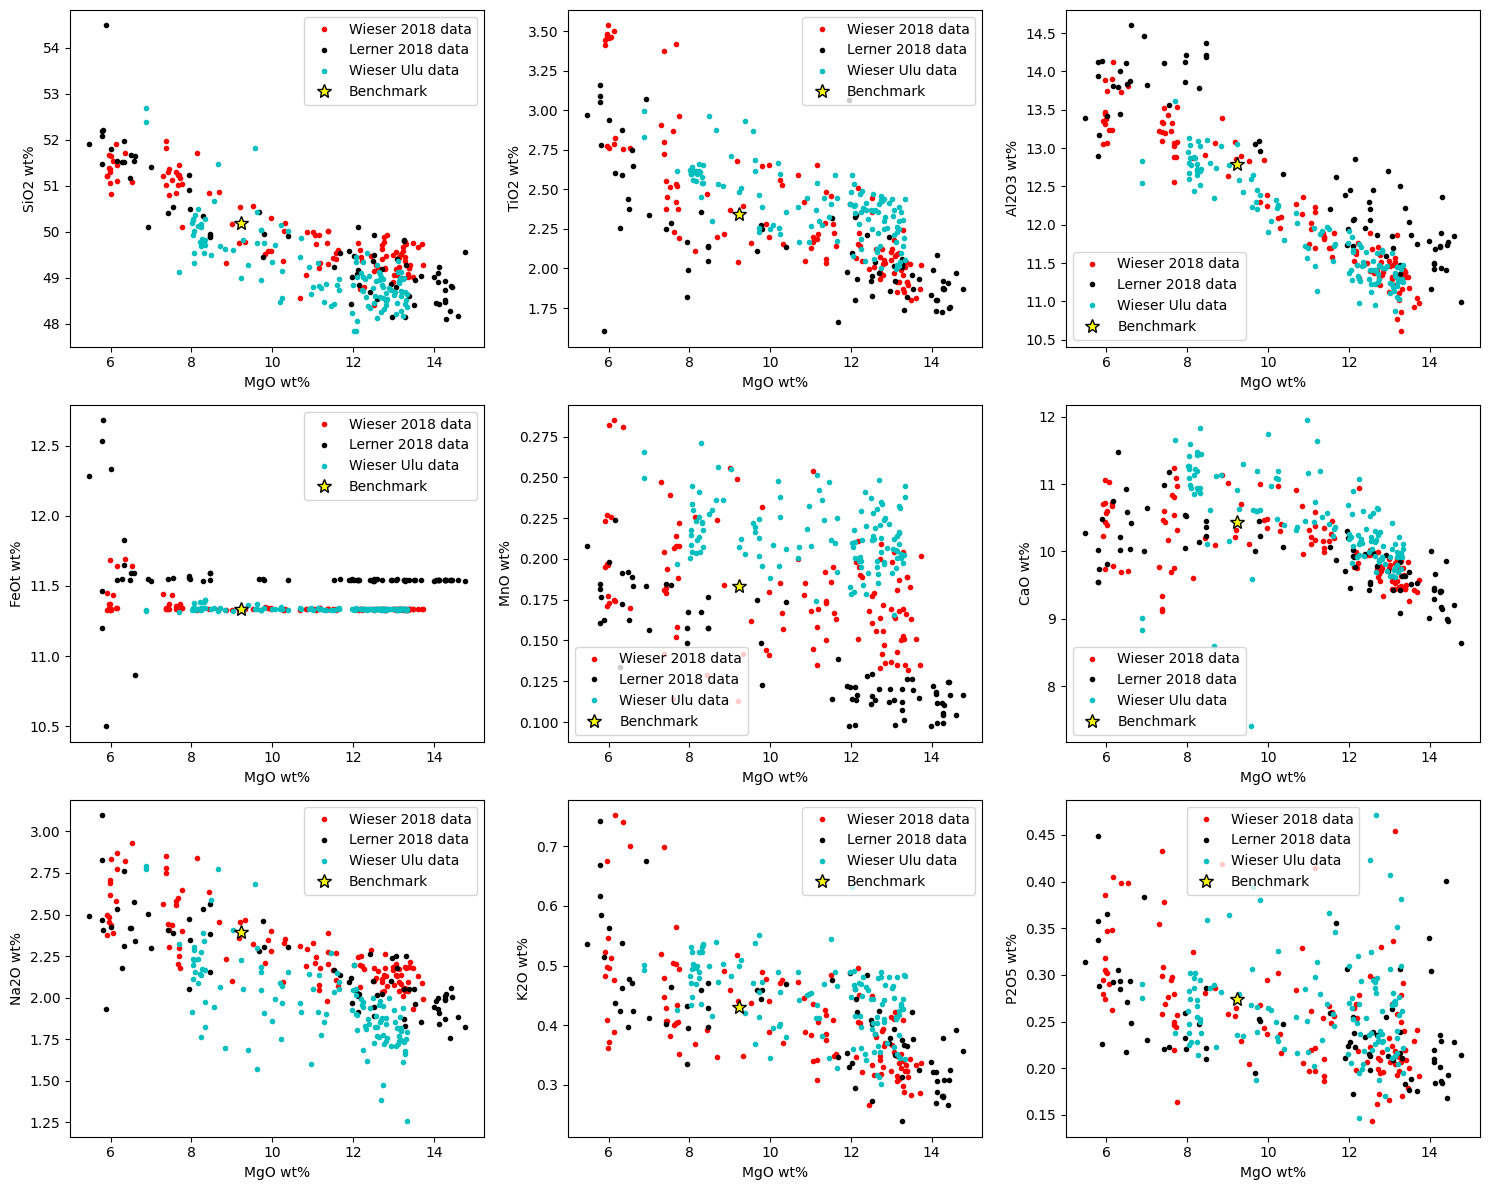

In [4]:
# Define oxides to loop through
oxides = ['SiO2', 'TiO2', 'Al2O3', 'FeOt', 'MnO', 'CaO', 'Na2O', 'K2O', 'P2O5']

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # Adjust grid size based on number of oxides

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through oxides and plot
for i, oxide in enumerate(oxides):
    ax = axes[i]
    ax.plot(df['MgO'], df[oxide], '.r', label="Wieser 2018 data")
    ax.plot(df_L['MgO'], df_L[oxide], '.k', label='Lerner 2018 data')
    ax.plot(df_ulu['MgO'], df_ulu[oxide], '.c', label='Wieser Ulu data')
    ax.plot(ideal_comp['MgO'], ideal_comp[oxide], '*k', ms=10, mfc='yellow', label="Benchmark")
    ax.set_xlabel('MgO wt%')
    ax.set_ylabel(f'{oxide} wt%')
    ax.legend()


# Adjust layout
fig.tight_layout()

## Lets justify the volatile contents

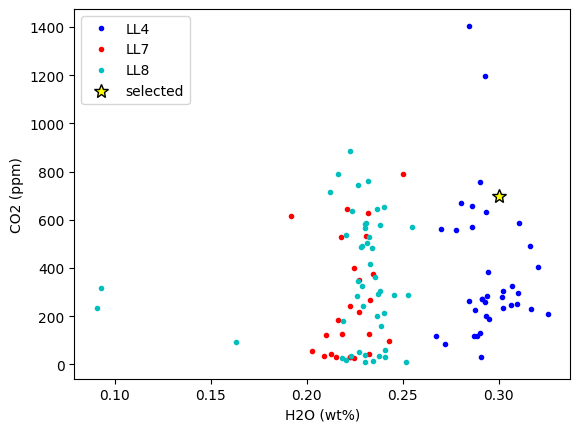

In [5]:
# Choose volatile contents - based on highest values for LL4 may sample
H2O_Liq=0.3
CO2_Liq=700
plt.plot(df['H2O'].loc[df['Label'].str.contains('LL4')], df['CO2'].loc[df['Label'].str.contains('LL4')]*10**4, '.b', label='LL4')
plt.plot(df['H2O'].loc[df['Label'].str.contains('LL7')], df['CO2'].loc[df['Label'].str.contains('LL7')]*10**4, '.r', label='LL7')
plt.plot(df['H2O'].loc[df['Label'].str.contains('LL8')], df['CO2'].loc[df['Label'].str.contains('LL8')]*10**4, '.c', label='LL8')
# Visually assessed a good start for LL4
plt.plot(H2O_Liq, CO2_Liq, '*k', mfc='yellow', ms=10, label='selected')
plt.xlabel('H2O (wt%)')
plt.ylabel('CO2 (ppm)')
plt.legend()


## What about sulfur
- The fissure 8 data is massively affected by sulfide formation in melt inclusions, shown by the false correlation with MgO

Text(0, 0.5, 'S (ppm)')

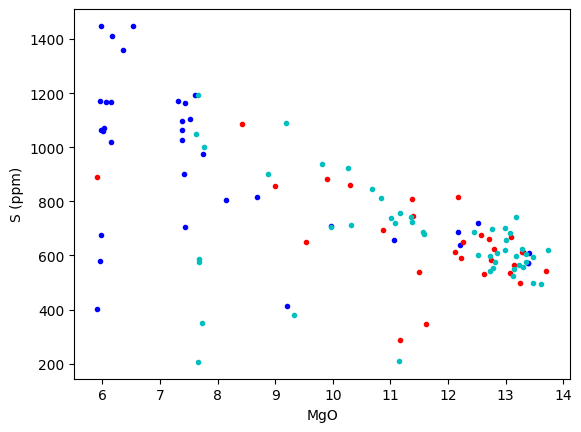

In [6]:
plt.plot(df['MgO'].loc[df['Label'].str.contains('LL4')], df['S_ppm'].loc[df['Label'].str.contains('LL4')], '.b', label='LL4')
plt.plot(df['MgO'].loc[df['Label'].str.contains('LL7')], df['S_ppm'].loc[df['Label'].str.contains('LL7')], '.r', label='LL7')
plt.plot(df['MgO'].loc[df['Label'].str.contains('LL8')], df['S_ppm'].loc[df['Label'].str.contains('LL8')], '.c', label='LL8')
# Visually assessed a good start for LL4
plt.xlabel('MgO')
plt.ylabel('S (ppm)')

## the better data is from Ulu (Wieser et al. 2020) and other eruptions (Sides et al. 2014) - where melt inclusions underwent less PEC.
 - Choose a S content based on the values bewteen 8 and 10 that is also a nice number

Text(0, 0.5, 'S_PEC')

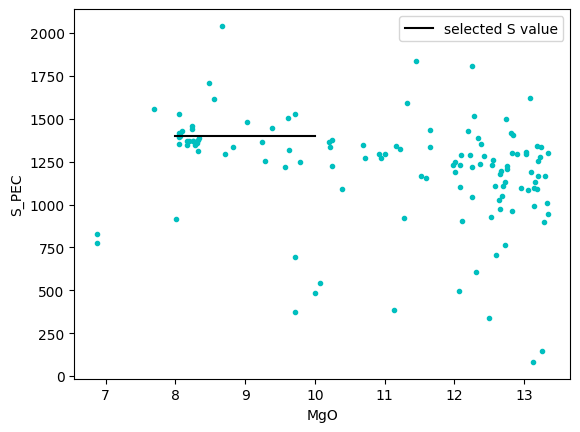

In [7]:
S_ppm=1400
plt.plot(df_ulu['MgO'], df_ulu['S_PEC'], '.c')
plt.plot([8, 10], [S_ppm, S_ppm], '-k', label='selected S value')
plt.legend()
plt.xlabel('MgO')
plt.ylabel('S_PEC')

In [8]:
ideal_comp_df = pd.DataFrame([ideal_comp.round(2)])
ideal_comp_df['H2O_wt%']=H2O_Liq
ideal_comp_df['CO2_ppm']=CO2_Liq
ideal_comp_df['S_ppm']=S_ppm
ideal_comp_df['Temp']=1200 # V close to helz and thornber, and nice number
ideal_comp_df['Fe3FeT']=0.15 # set at Kilauea
# Recast into FeOT



ideal_comp_df

,S_ppm,SiO2,TiO2,Al2O3,FeO,Fe2O3,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,H2O,FeOt,H2O_wt%,CO2_ppm,Temp,Fe3FeT
0,1400,50.19,2.34,12.79,9.64,1.89,0.18,9.23,10.44,2.39,0.43,0.27,0.03,0.26,11.34,0.3,700,1200,0.15


In [9]:
ideal_comp_df.to_clipboard(excel=True)